# RNN — AAPL Stock Price Prediction - Torch

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Load & Preprocess Data

In [9]:
# Load data
data = pd.read_csv('top50_adjclose_2010_2025.csv')
apple_data = data[['Date', 'AAPL']].copy()
apple_data['Date'] = pd.to_datetime(apple_data['Date'])
apple_data = apple_data.dropna().reset_index(drop=True)

# Raw prices as numpy array
apple_prices = apple_data['AAPL'].values.reshape(-1, 1)

# Sequence creation — same logic as the notebook
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 60
X_raw, y_raw = create_sequences(apple_prices, lookback)

# Train / Val / Test split
train_size = int(0.7 * len(X_raw))
val_size   = int(0.15 * len(X_raw))

X_train_raw, y_train_raw = X_raw[:train_size],                    y_raw[:train_size]
X_val_raw,   y_val_raw   = X_raw[train_size:train_size+val_size], y_raw[train_size:train_size+val_size]
X_test_raw,  y_test_raw  = X_raw[train_size+val_size:],           y_raw[train_size+val_size:]

# Fit scaler on TRAIN only, then apply to all splits
scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
y_train = scaler.transform(y_train_raw)

X_val = scaler.transform(X_val_raw.reshape(-1, 1)).reshape(X_val_raw.shape)
y_val = scaler.transform(y_val_raw)

X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
y_test = scaler.transform(y_test_raw)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Input shape: {X_train.shape}")  # (samples, lookback, 1)

Train: 2774 | Val: 594 | Test: 595
Input shape: (2774, 60, 1)


In [10]:
# Convert to float32 tensors directly
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Wrap in TensorDataset and create loaders
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=64, shuffle=False)

# Sanity check
X_batch, y_batch = next(iter(train_loader))
print(f"X batch shape: {X_batch.shape}")  # (64, 60, 1)
print(f"y batch shape: {y_batch.shape}")  # (64, 1)

X batch shape: torch.Size([64, 60, 1])
y batch shape: torch.Size([64, 1])


## 2. Model Definition and Training

In [11]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            nonlinearity='tanh'
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 25),
            nn.ReLU(),
            nn.Linear(25, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)  
        out = out[:, -1, :]    
        out = self.fc(out)
        return out


model = RNNModel()
print(model)

RNNModel(
  (rnn): RNN(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
    (2): Linear(in_features=25, out_features=1, bias=True)
  )
)


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = RNNModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 200

# Early stopping setup
best_val_loss = float('inf')
patience = 20
patience_counter = 0
best_weights = None

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_loader.dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            val_loss += criterion(preds, y_batch).item() * len(X_batch)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --- Gradient Flow & Weight Magnitudes (every 10 epochs) ---
    if (epoch + 1) % 10 == 0:
        print(f"\nEpoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        print(f"  {'Layer':30} | {'Grad Mean':>12} | {'W Mean':>12} | {'W Std':>12}")
        print(f"  {'-'*72}")
        for name, param in model.named_parameters():
            grad = param.grad.abs().mean().item() if param.grad is not None else float('nan')
            print(f"  {name:30} | {grad:12.6f} | {param.data.abs().mean().item():12.6f} | {param.data.std().item():12.6f}")

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Restore best weights
model.load_state_dict(best_weights)
print("Restored best weights.")

Using device: cpu

Epoch  10 | Train Loss: 0.000315 | Val Loss: 0.016693
  Layer                          |    Grad Mean |       W Mean |        W Std
  ------------------------------------------------------------------------
  rnn.weight_ih_l0               |     0.001503 |     0.082346 |     0.088967
  rnn.weight_hh_l0               |     0.000317 |     0.072100 |     0.083197
  rnn.bias_ih_l0                 |     0.003566 |     0.064566 |     0.078074
  rnn.bias_hh_l0                 |     0.003566 |     0.075323 |     0.083066
  rnn.weight_ih_l1               |     0.000078 |     0.071202 |     0.083082
  rnn.weight_hh_l1               |     0.000216 |     0.071453 |     0.082669
  rnn.bias_ih_l1                 |     0.000869 |     0.072250 |     0.081900
  rnn.bias_hh_l1                 |     0.000869 |     0.078930 |     0.090567
  fc.0.weight                    |     0.000208 |     0.070598 |     0.082504
  fc.0.bias                      |     0.000808 |     0.069439 |     0.0

C:\Users\felip\AppData\Local\Temp\ipykernel_53760\3331847640.py:56: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  print(f"  {name:30} | {grad:12.6f} | {param.data.abs().mean().item():12.6f} | {param.data.std().item():12.6f}")



Epoch  20 | Train Loss: 0.000302 | Val Loss: 0.016639
  Layer                          |    Grad Mean |       W Mean |        W Std
  ------------------------------------------------------------------------
  rnn.weight_ih_l0               |     0.001354 |     0.088652 |     0.095083
  rnn.weight_hh_l0               |     0.000247 |     0.072347 |     0.083550
  rnn.bias_ih_l0                 |     0.002048 |     0.063239 |     0.076949
  rnn.bias_hh_l0                 |     0.002048 |     0.073547 |     0.080873
  rnn.weight_ih_l1               |     0.000071 |     0.071507 |     0.083802
  rnn.weight_hh_l1               |     0.000187 |     0.071353 |     0.082618
  rnn.bias_ih_l1                 |     0.000534 |     0.072019 |     0.081771
  rnn.bias_hh_l1                 |     0.000534 |     0.078935 |     0.090481
  fc.0.weight                    |     0.000176 |     0.070642 |     0.082657
  fc.0.bias                      |     0.000490 |     0.069806 |     0.078031
  fc.2.weigh

## 3. Final Results

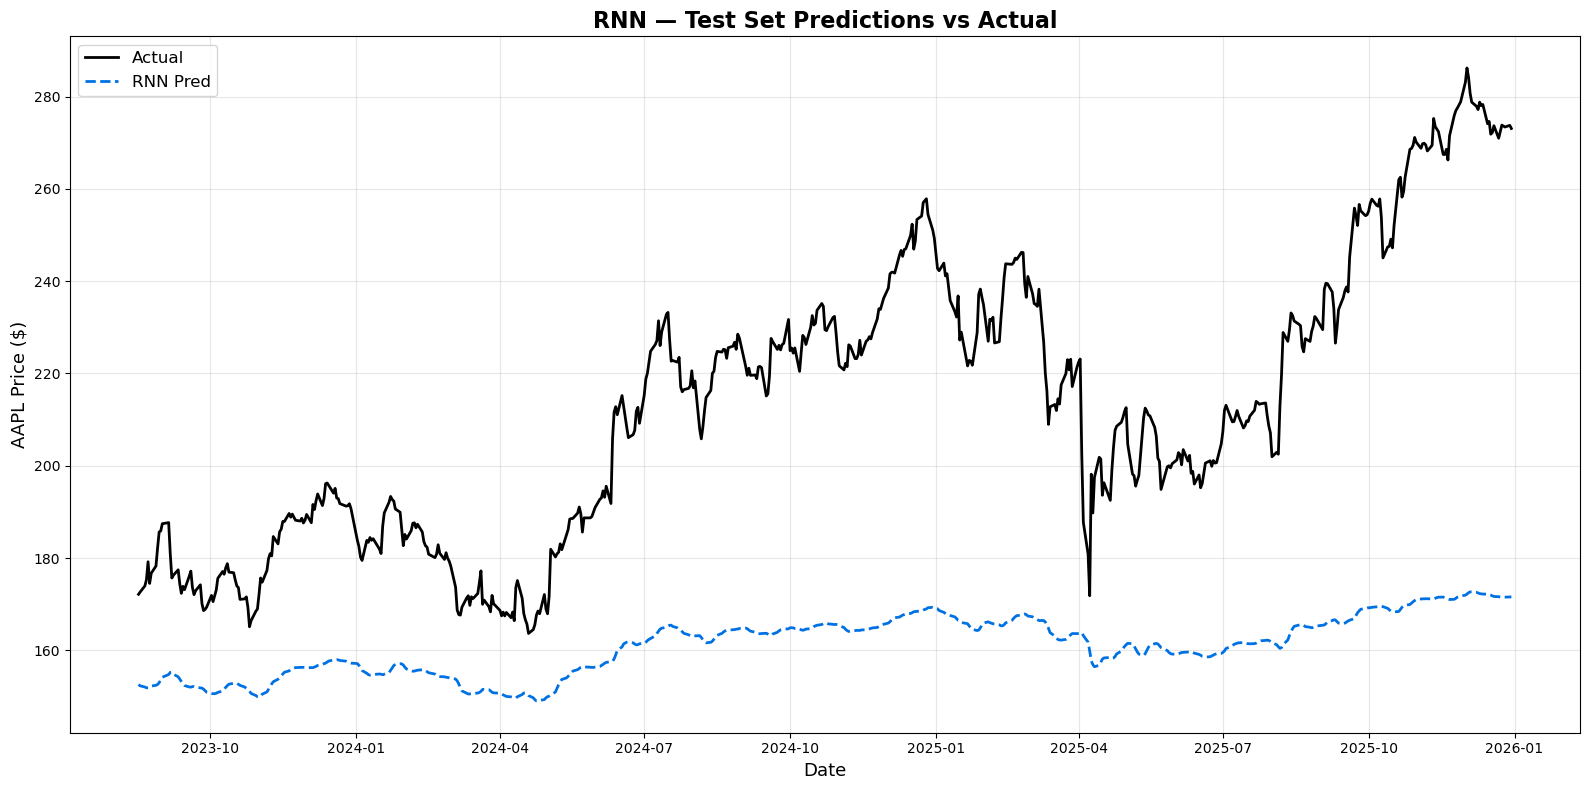

MAE:  $51.68
RMSE: $57.04
MAPE: 23.20%


In [13]:
model.eval()
preds_scaled, actuals_scaled = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        preds_scaled.append(preds)
        actuals_scaled.append(y_batch.numpy())

preds_scaled  = np.concatenate(preds_scaled,  axis=0)
actuals_scaled = np.concatenate(actuals_scaled, axis=0)

# Inverse transform back to original price scale
preds_actual   = scaler.inverse_transform(preds_scaled)
actuals_actual = scaler.inverse_transform(actuals_scaled)

# Get test dates
test_start_idx = train_size + val_size + lookback
test_dates = apple_data['Date'].iloc[test_start_idx:test_start_idx + len(actuals_actual)].values

# Plot
plt.figure(figsize=(16, 8))
plt.plot(test_dates, actuals_actual, label='Actual',   color='black',  linewidth=2)
plt.plot(test_dates, preds_actual,   label='RNN Pred', color='#0071e3', linewidth=2, linestyle='--')
plt.title('RNN — Test Set Predictions vs Actual', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('AAPL Price ($)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Metrics
mae  = mean_absolute_error(actuals_actual, preds_actual)
rmse = np.sqrt(mean_squared_error(actuals_actual, preds_actual))
mape = np.mean(np.abs((actuals_actual - preds_actual) / actuals_actual)) * 100
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")